In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Kütüphaneler yüklendi!")

Kütüphaneler yüklendi!


In [2]:
import urllib.request

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
urllib.request.urlretrieve(url, "titanic.csv")

df = pd.read_csv("titanic.csv")
print("Veri yüklendi!")
print("Boyut:", df.shape)
df.head()

Veri yüklendi!
Boyut: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Eksik değerler:")
print(df.isnull().sum())

Eksik değerler:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Age eksiklerini medyan ile doldur
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked eksiklerini en sık değerle doldur
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin sütununu sil - çok fazla eksik var
df = df.drop(columns=["Cabin", "Ticket", "Name", "PassengerId"])

print("Temizleme tamamlandı!")
print("Kalan eksikler:")
print(df.isnull().sum())

Temizleme tamamlandı!
Kalan eksikler:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


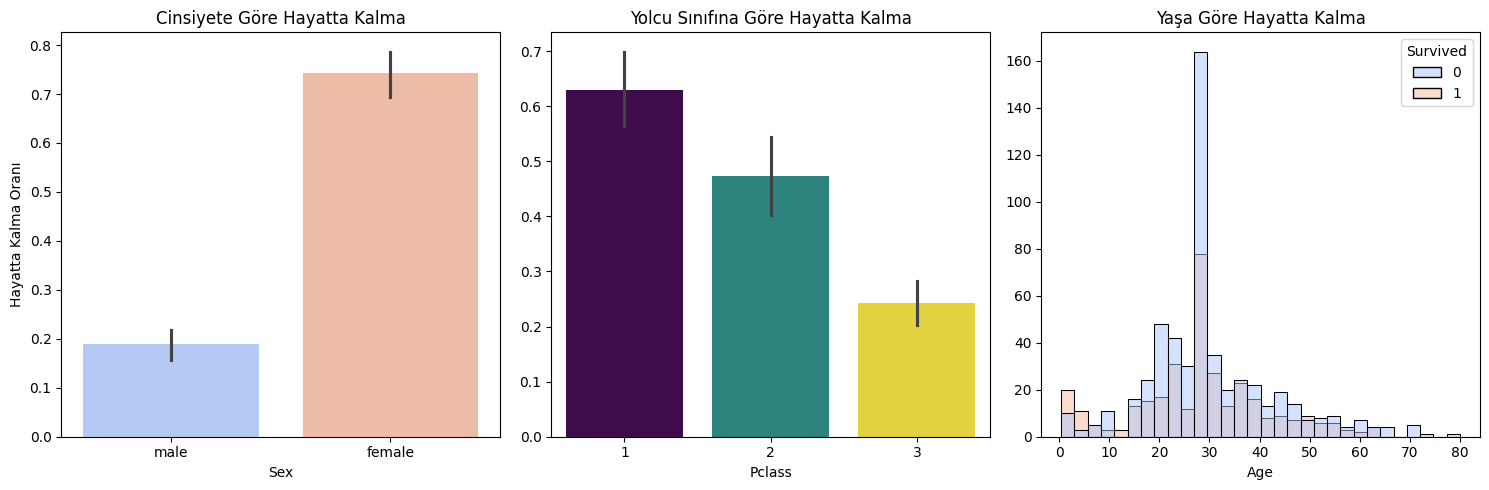

Grafik kaydedildi!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cinsiyete göre hayatta kalma
sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0], hue="Sex", palette="coolwarm", legend=False)
axes[0].set_title("Cinsiyete Göre Hayatta Kalma")
axes[0].set_ylabel("Hayatta Kalma Oranı")

# Sınıfa göre hayatta kalma
sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], hue="Pclass", palette="viridis", legend=False)
axes[1].set_title("Yolcu Sınıfına Göre Hayatta Kalma")
axes[1].set_ylabel("")

# Yaşa göre hayatta kalma dağılımı
sns.histplot(data=df, x="Age", hue="Survived", ax=axes[2], bins=30, palette="coolwarm")
axes[2].set_title("Yaşa Göre Hayatta Kalma")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig("hayatta_kalma_analizi.png", dpi=150)
plt.show()

print("Grafik kaydedildi!")

In [6]:
# Sex sütununu sayıya çevir (male=0, female=1)
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

# Özellikler ve hedef değişkeni ayır
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Eğitim ve test setine böl (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (712, 7)
Test seti: (179, 7)


In [7]:
modeller = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

sonuclar = {}

for isim, model in modeller.items():
    model.fit(X_train, y_train)
    tahmin = model.predict(X_test)
    accuracy = accuracy_score(y_test, tahmin)
    sonuclar[isim] = accuracy
    print(f"{isim}: %{accuracy*100:.2f}")

Logistic Regression: %81.01
Decision Tree: %78.21
Random Forest: %82.12
K-Nearest Neighbors: %72.07


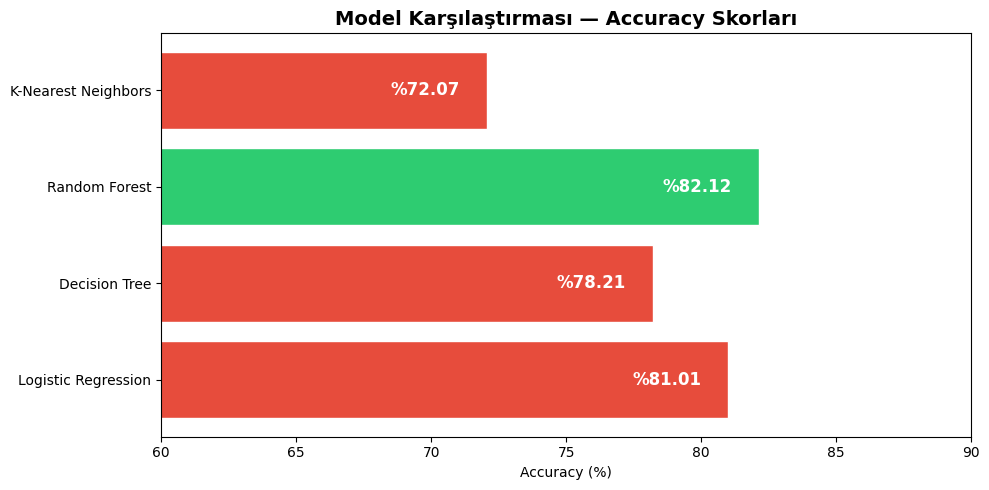

Grafik kaydedildi!


In [8]:
plt.figure(figsize=(10, 5))

renkler = ["#e74c3c" if v < max(sonuclar.values()) else "#2ecc71" for v in sonuclar.values()]

bars = plt.barh(list(sonuclar.keys()), 
                [v*100 for v in sonuclar.values()], 
                color=renkler, edgecolor="white")

for bar, val in zip(bars, sonuclar.values()):
    plt.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
             f"%{val*100:.2f}", va="center", ha="right", 
             color="white", fontweight="bold", fontsize=12)

plt.title("Model Karşılaştırması — Accuracy Skorları", fontsize=14, fontweight="bold")
plt.xlabel("Accuracy (%)")
plt.xlim(60, 90)
plt.tight_layout()
plt.savefig("model_karsilastirma.png", dpi=150)
plt.show()

print("Grafik kaydedildi!")

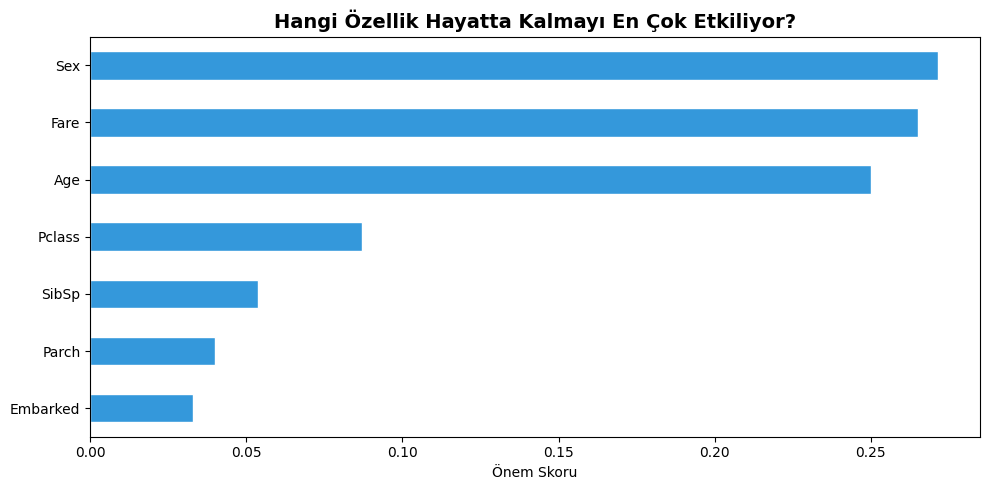

Grafik kaydedildi!


In [9]:
# Random Forest'ın feature importance değerleri
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

onem = pd.Series(rf_model.feature_importances_, index=X.columns)
onem = onem.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
onem.plot(kind="barh", color="#3498db", edgecolor="white")
plt.title("Hangi Özellik Hayatta Kalmayı En Çok Etkiliyor?", fontsize=14, fontweight="bold")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Grafik kaydedildi!")

In [10]:
def hayatta_kalir_miydin(cinsiyet, yas, sinif, ucret, kardes_es=0, ebeveyn_cocuk=0, liman=2):
    cinsiyet_enc = 1 if cinsiyet.lower() == "female" else 0
    veri = pd.DataFrame([[sinif, cinsiyet_enc, yas, kardes_es, ebeveyn_cocuk, ucret, liman]],
                        columns=["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"])
    tahmin = rf_model.predict(veri)[0]
    olasilik = rf_model.predict_proba(veri)[0][1]
    
    if tahmin == 1:
        print(f"✅ HAYATTASINكان! Hayatta kalma olasılığın: %{olasilik*100:.1f}")
    else:
        print(f"❌ NE YAZIK... Hayatta kalma olasılığın: %{olasilik*100:.1f}")

# Test edelim — sen Titanic'te olsaydın:
print("--- Yusuf Emre (22 yaş, erkek, 3. sınıf) ---")
hayatta_kalir_miydin(cinsiyet="male", yas=22, sinif=3, ucret=8)

print("\n--- 1. sınıf kadın yolcu ---")
hayatta_kalir_miydin(cinsiyet="female", yas=22, sinif=1, ucret=100)

--- Yusuf Emre (22 yaş, erkek, 3. sınıf) ---
❌ NE YAZIK... Hayatta kalma olasılığın: %29.0

--- 1. sınıf kadın yolcu ---
❌ NE YAZIK... Hayatta kalma olasılığın: %30.0


In [11]:
def hayatta_kalir_miydin(cinsiyet, yas, sinif, ucret, kardes_es=0, ebeveyn_cocuk=0, liman=2):
    cinsiyet_enc = 0 if cinsiyet.lower() == "female" else 1
    veri = pd.DataFrame([[sinif, cinsiyet_enc, yas, kardes_es, ebeveyn_cocuk, ucret, liman]],
                        columns=["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"])
    tahmin = rf_model.predict(veri)[0]
    olasilik = rf_model.predict_proba(veri)[0][1]
    
    if tahmin == 1:
        print(f"✅ HAYATTASINكان! Hayatta kalma olasılığın: %{olasilik*100:.1f}")
    else:
        print(f"❌ NE YAZIK... Hayatta kalma olasılığın: %{olasilik*100:.1f}")

print("--- Yusuf Emre (22 yaş, erkek, 3. sınıf) ---")
hayatta_kalir_miydin(cinsiyet="male", yas=22, sinif=3, ucret=8)

print("\n--- 1. sınıf kadın yolcu ---")
hayatta_kalir_miydin(cinsiyet="female", yas=22, sinif=1, ucret=100)

--- Yusuf Emre (22 yaş, erkek, 3. sınıf) ---
❌ NE YAZIK... Hayatta kalma olasılığın: %1.0

--- 1. sınıf kadın yolcu ---
✅ HAYATTASINكان! Hayatta kalma olasılığın: %100.0


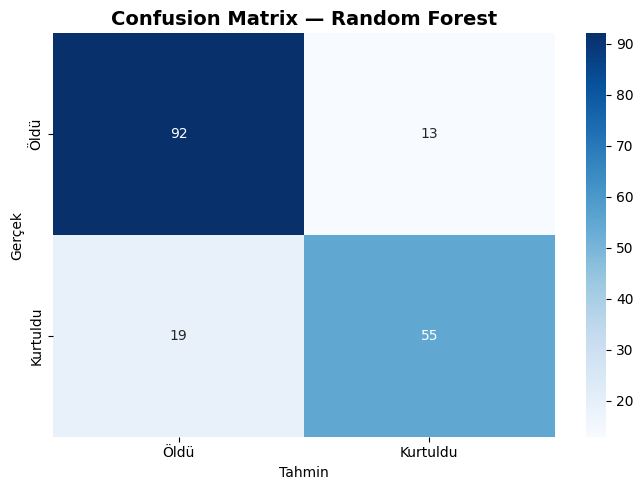

              precision    recall  f1-score   support

        Öldü       0.83      0.88      0.85       105
    Kurtuldu       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [12]:
tahminler = rf_model.predict(X_test)
cm = confusion_matrix(y_test, tahminler)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Öldü", "Kurtuldu"],
            yticklabels=["Öldü", "Kurtuldu"])
plt.title("Confusion Matrix — Random Forest", fontsize=14, fontweight="bold")
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_test, tahminler, target_names=["Öldü", "Kurtuldu"]))